# Adult Income Prediction using Machine Learning

## Overview

This notebook focuses on the machine learning phase of the Adult Income Prediction project.

The dataset was first explored, analyzed, and cleaned using MySQL. The cleaned dataset was then imported into Google Colab, where exploratory data analysis, preprocessing, model training, and evaluation were performed.

Three classification models were trained:
- Logistic Regression
- Random Forest
- XGBoost

The objective is to identify the model that provides the best performance for predicting whether an individual's annual income exceeds $50K.

---

# 5. Machine Learning

## 5.1 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

##5.2 Load the Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving adult_income_final.csv to adult_income_final.csv


In [5]:
df = pd.read_csv("adult_income_final.csv", sep=";")

##5.3 Dataset Overview

In [6]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [7]:
df.shape

(45985, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45985 entries, 0 to 45984
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              45985 non-null  int64 
 1   workclass        45985 non-null  object
 2   fnlwgt           45985 non-null  int64 
 3   education        45985 non-null  object
 4   educational-num  45985 non-null  int64 
 5   marital-status   45985 non-null  object
 6   occupation       45985 non-null  object
 7   relationship     45985 non-null  object
 8   race             45985 non-null  object
 9   gender           45985 non-null  object
 10  capital-gain     45985 non-null  int64 
 11  capital-loss     45985 non-null  int64 
 12  hours-per-week   45985 non-null  int64 
 13  native-country   45985 non-null  object
 14  income           45985 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.3+ MB


In [9]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,45985.000000,4.598500e+04,45985.000000,45985.000000,45985.000000,45985.000000
mean,38.564880,1.898102e+05,10.129803,1115.495814,88.821964,40.952854
std,13.201852,1.054885e+05,2.562978,7593.446168,405.518277,12.011417
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176060e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783530e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.378190e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


This provides summary statistics for numerical features such as:

* Mean
* Standard deviation
* Minimum
* Maximum
* Quartiles

In [10]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


We already cleaned the data in SQL.

This step verifies that no missing values remain before moving to machine learning.

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

## 5.4 Exploratory Data Analysis (EDA)

### Target Variable Distribution

In [13]:
df['income'].value_counts()

,count
income,
<=50K,34569
>50K,11416


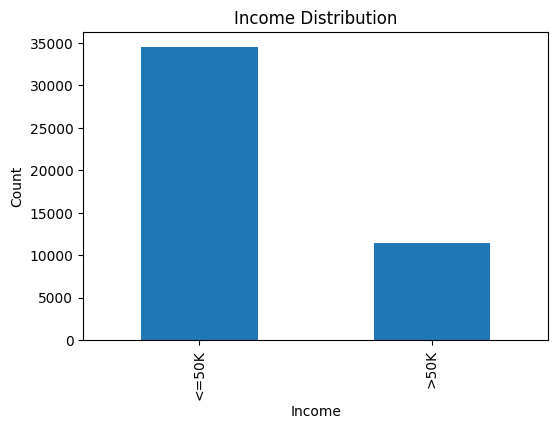

In [14]:
plt.figure(figsize=(6,4))
df['income'].value_counts().plot(kind='bar')

plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

The dataset contains a higher number of individuals earning ≤50K compared to those earning >50K, indicating a moderately imbalanced target variable. This distribution should be considered during model evaluation.

### Age Distribution

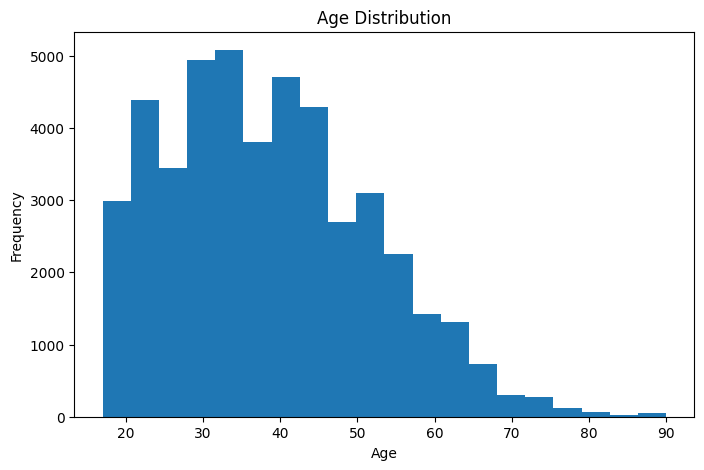

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

The age distribution is right-skewed, with most individuals falling between 25 and 50 years. The number of observations gradually decreases for older age groups.

### Education Distribution

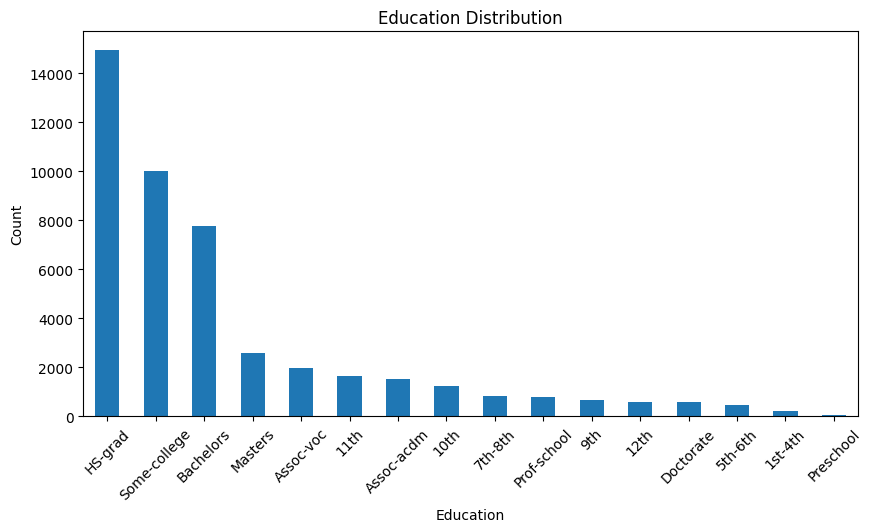

In [16]:
plt.figure(figsize=(10,5))
df['education'].value_counts().plot(kind='bar')

plt.title('Education Distribution')
plt.xlabel('Education')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

Most individuals have an education level of HS-grad, followed by Some-college and Bachelors. Higher educational qualifications such as Masters and Doctorate are comparatively less common.

Correlation Between Numerical Features

In [17]:
numeric_df = df.select_dtypes(include=['int64','float64'])

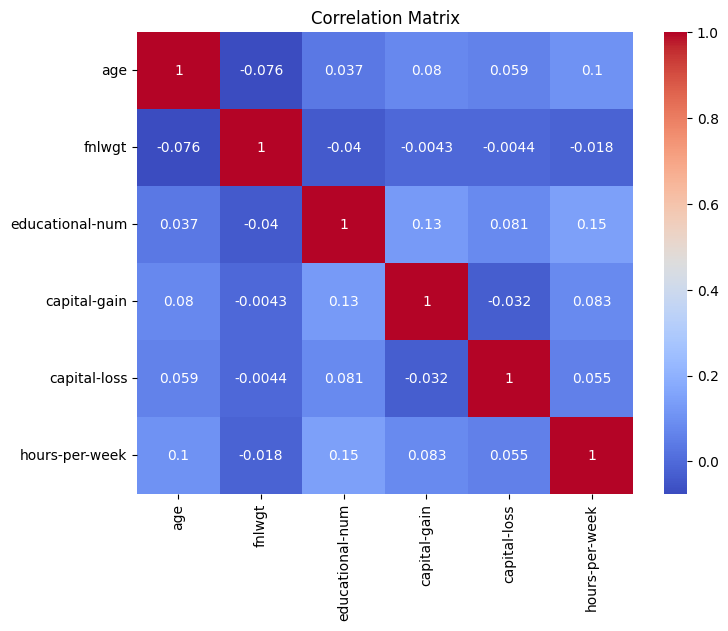

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

The numerical features exhibit relatively weak linear correlations with one another. The highest positive correlation is observed between educational-num and hours-per-week, while most other feature pairs show low correlation, indicating limited multicollinearity.

## 5.5 Data Preprocessing

In [19]:
X = df.drop('income', axis=1)
y = df['income']

The dataset was divided into independent features (X) and the target variable (y). The input features are used to train the machine learning model, while the target variable represents the income class to be predicted.

In [20]:
encoder = LabelEncoder()

for column in X.select_dtypes(include='object').columns:
    X[column] = encoder.fit_transform(X[column])

y = encoder.fit_transform(y)

Categorical variables were converted into numerical values using Label Encoding, enabling machine learning algorithms to process the data.

In [21]:
X.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,2,226802,1,7,4,6,3,2,1,0,0,40,38
1,38,2,89814,11,9,2,4,0,4,1,0,0,50,38
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38
3,44,2,160323,15,10,2,6,0,2,1,7688,0,40,38
4,34,2,198693,0,6,4,7,1,4,1,0,0,30,38


In [22]:
y[:5]

array([0, 0, 1, 1, 0])

## 5.6 Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (36788, 14)
Testing Features  : (9197, 14)
Training Labels   : (36788,)
Testing Labels    : (9197,)


The dataset was divided into 80% training data and 20% testing data. The training set is used to build the model, while the testing set is used to evaluate its performance on unseen data.

## 5.7 Model Training

## Model 1 — Logistic Regression

In [25]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [26]:
y_pred_lr = logistic_model.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification report\n",classification_report(y_test, y_pred_lr))

Accuracy: 0.8024355768185277
Classification report
               precision    recall  f1-score   support

           0       0.83      0.94      0.88      6972
           1       0.66      0.38      0.48      2225

    accuracy                           0.80      9197
   macro avg       0.74      0.66      0.68      9197
weighted avg       0.79      0.80      0.78      9197



In [28]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[6527  445]
 [1372  853]]


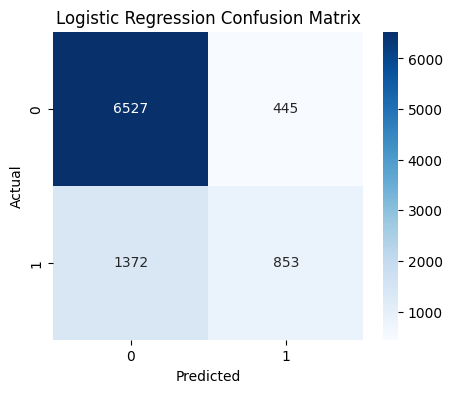

In [29]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

The Logistic Regression model achieved an overall accuracy of 80.24%. It performed well in identifying individuals earning ≤50K, but showed lower recall for the >$50K class, indicating that a considerable number of high-income individuals were misclassified. This suggests that while Logistic Regression provides a strong baseline, a more advanced model may improve the prediction of the minority class.

## Model 2 — Random Forest

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
y_pred_rf = rf_model.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification report\n",classification_report(y_test, y_pred_rf))

Accuracy: 0.8499510710014135
Classification report
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      6972
           1       0.72      0.61      0.66      2225

    accuracy                           0.85      9197
   macro avg       0.80      0.77      0.78      9197
weighted avg       0.84      0.85      0.85      9197



In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[6451  521]
 [ 859 1366]]


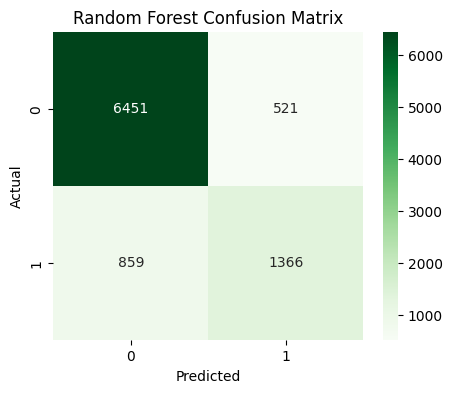

In [34]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

The Random Forest model achieved an overall accuracy of 84.99%, outperforming the Logistic Regression model. It showed noticeable improvements in precision, recall, and F1-score for the >$50K income class, demonstrating a better ability to identify high-income individuals. These results indicate that Random Forest captures more complex patterns in the dataset and provides stronger predictive performance.

The recall for the >$50K class increased from 38% to 61%, meaning Random Forest identifies many more high-income individuals correctly

## Model 3 — XGBoost

In [35]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

In [36]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [37]:
y_pred_xgb = xgb_model.predict(X_test)

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification report\n",classification_report(y_test, y_pred_xgb))

Accuracy: 0.8714798303794715
Classification report
               precision    recall  f1-score   support

           0       0.89      0.94      0.92      6972
           1       0.79      0.64      0.71      2225

    accuracy                           0.87      9197
   macro avg       0.84      0.79      0.81      9197
weighted avg       0.87      0.87      0.87      9197



In [39]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

[[6588  384]
 [ 798 1427]]


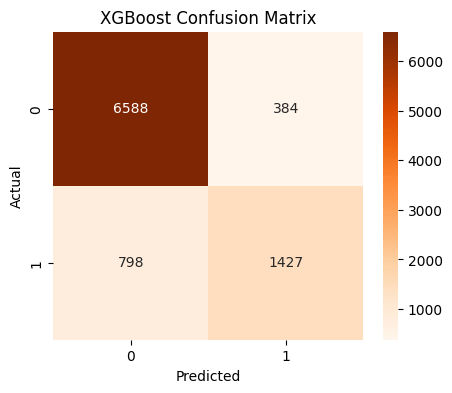

In [40]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

XGBoost was trained as the final classification model to evaluate whether a gradient boosting approach could achieve better predictive performance than Logistic Regression and Random Forest.

The XGBoost model achieved the highest overall accuracy of 87.15% among all the evaluated models. It also produced the best precision, recall, and F1-score for the >$50K income class, demonstrating its superior ability to correctly identify high-income individuals. These results indicate that XGBoost is the most effective model for this prediction task.

The XGBoost model achieved the highest overall accuracy of 87.15% among all the evaluated models. It also produced the best precision, recall, and F1-score for the >$50K income class, demonstrating its superior ability to correctly identify high-income individuals. These results indicate that XGBoost is the most effective model for this prediction task.

In [41]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
7,relationship,0.483597
4,educational-num,0.130918
10,capital-gain,0.097239
5,marital-status,0.097188
11,capital-loss,0.043531
6,occupation,0.031593
0,age,0.030063
12,hours-per-week,0.021990
9,gender,0.016064
1,workclass,0.014332


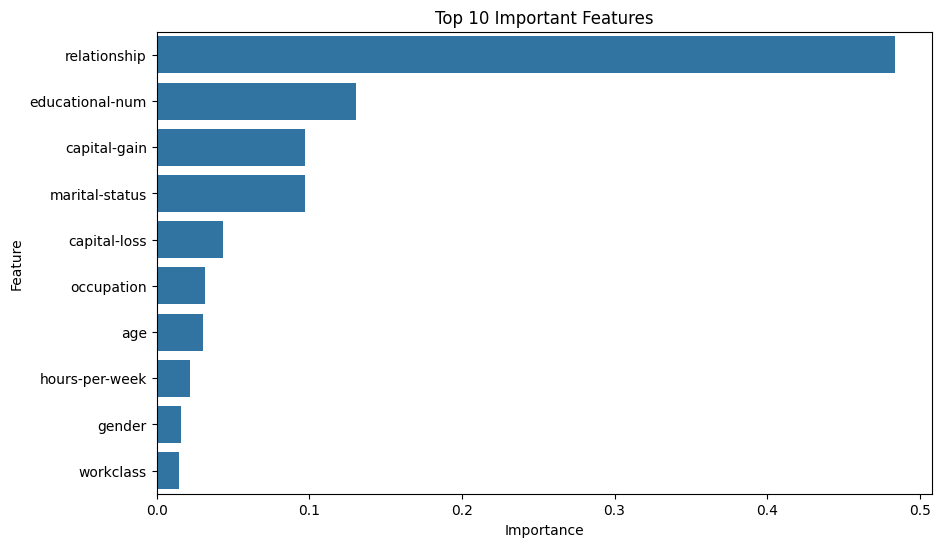

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

The feature importance analysis shows which variables contributed most to the prediction of annual income. These features had the greatest influence on the XGBoost model during classification.

## 5.8 Model Comparison

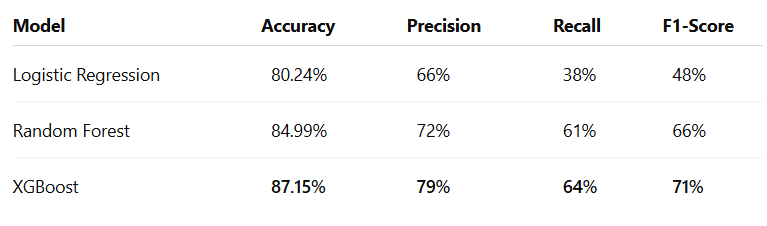

## 5.9 Best Model Selection

Based on the evaluation metrics, **XGBoost** was selected as the final model for this project. It achieved the highest accuracy (**87.15%**) while also providing the strongest precision, recall, and F1-score for the high-income class (>50K). These results indicate that XGBoost offers the best balance between overall performance and the ability to correctly classify both income categories.

---
# 6. Conclusion

In this project, an end-to-end machine learning solution was developed to predict whether an individual's annual income exceeds **$50K** based on demographic and employment-related information.

The project began with data exploration and cleaning in **MySQL**, where missing values, duplicate records, and data quality issues were addressed. After preparing the dataset, it was imported into **Google Colab** for exploratory data analysis, preprocessing, feature encoding, and machine learning.

Three classification models—**Logistic Regression**, **Random Forest**, and **XGBoost**—were trained and evaluated. While Logistic Regression provided a solid baseline and Random Forest improved the overall performance, **XGBoost** produced the best results with an accuracy of **87.15%** and the strongest overall classification metrics.

This project demonstrates the complete workflow of a data science solution, from raw data preparation to model development and evaluation. It also highlights the importance of proper data cleaning, exploratory analysis, and model selection in building reliable predictive models.


-------------------
